<a href="https://colab.research.google.com/github/Ramses-Monjaras/Data-Processing-Visualization/blob/main/Project_Create_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Games using the Unreal Engine 5
## Ramses Monjaras
## Data Processingn Visualization
## CPSMA 4-313-01
## Nicholas Jacob

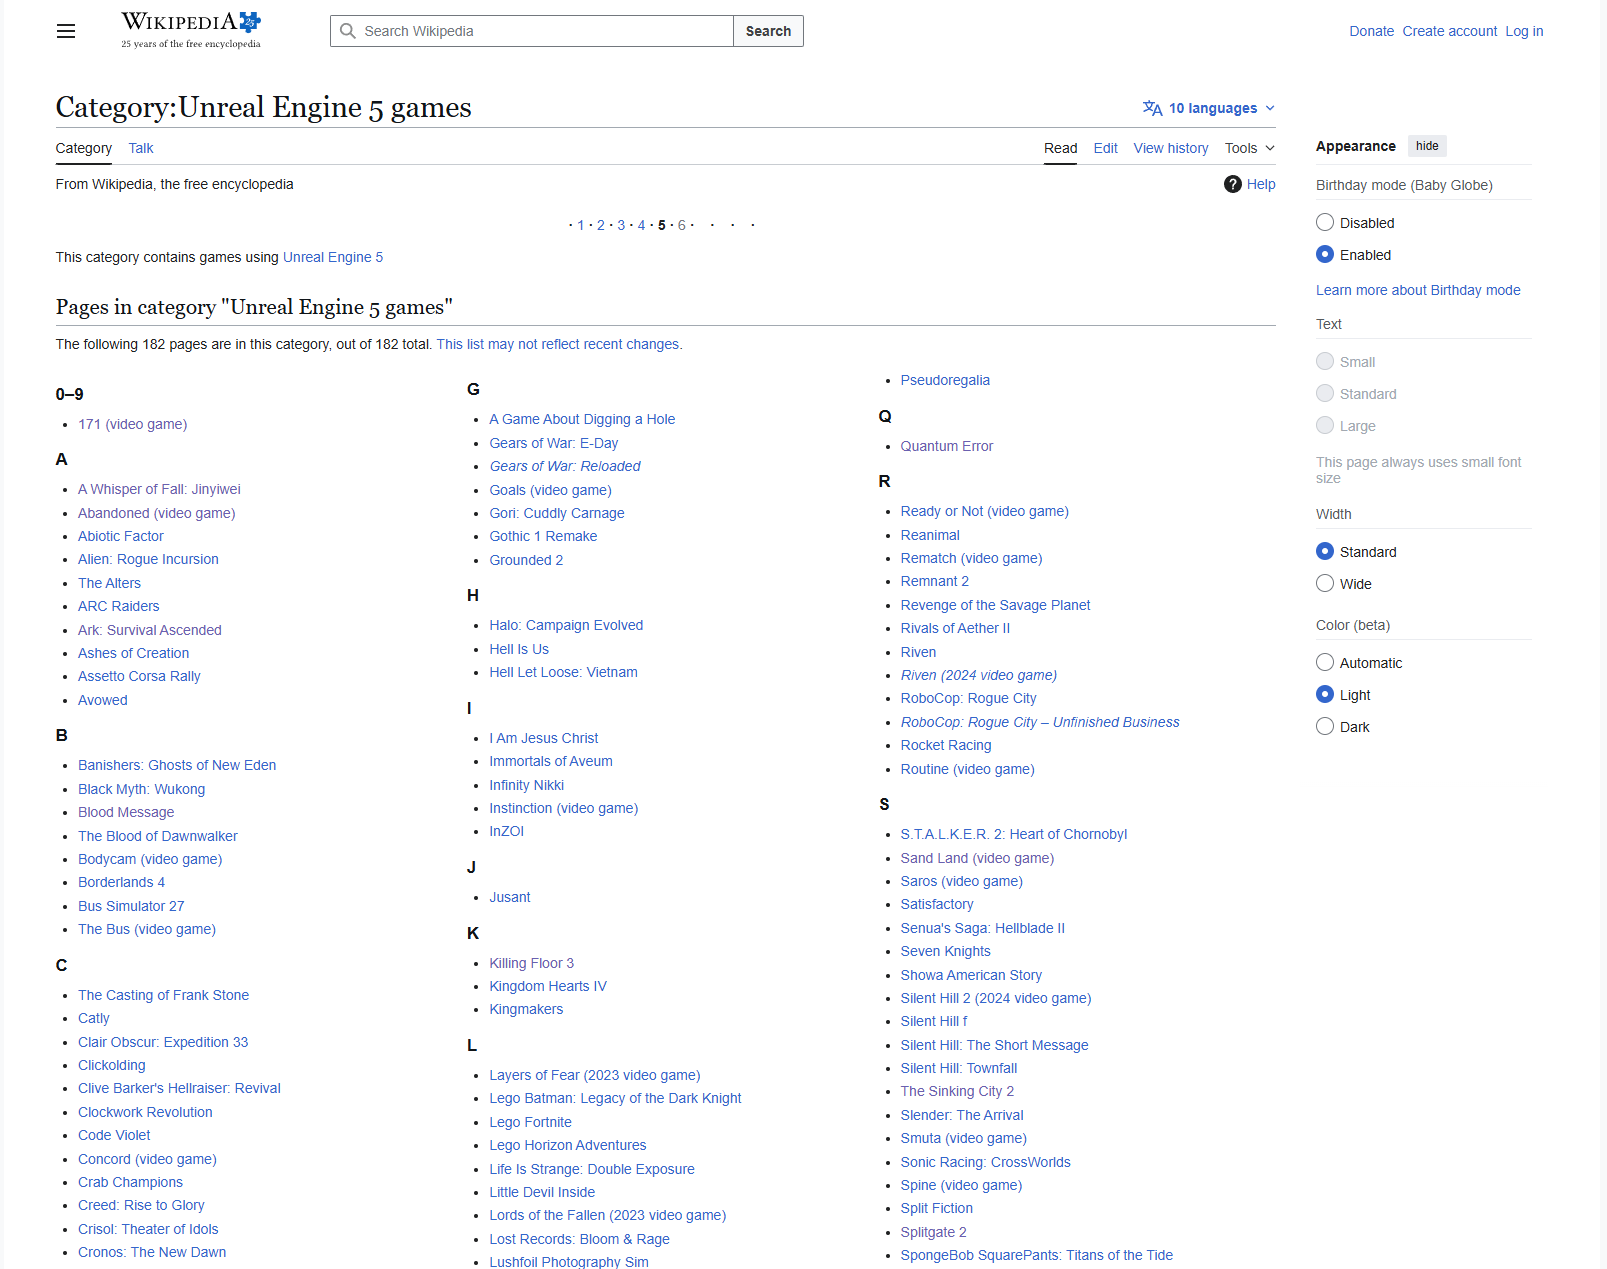

Link to the website: https://en.wikipedia.org/wiki/Category:Unreal_Engine_5_games

This data is interesting too see how many different types of games can be made using the Unreal Engine 5. I coundn't find any usable tables, many websites only list a few games and the website doesn't provide a lot of infomation about each game, just the title and a description on what the game is about.

In [ ]:
!pip install requests beautifulsoup4 pandas lxml tqdm

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from tqdm.notebook import tqdm
from google.colab import files

def clean_text(text):
    """Clean and normalize text"""
    if not text:
        return 'N/A'
    # Remove citations like [1], [2], etc.
    text = re.sub(r'\[\d+\]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text.strip()

def extract_pure_release_date(cell):
    """
    Extract ONLY the release date, completely removing any platform information
    """
    if not cell:
        return 'N/A'

    # Get text content
    text = cell.get_text(strip=True)
    text = clean_text(text)

    # List of platform keywords to remove
    platform_keywords = [
        'Windows', 'Win', 'PC',
        'PlayStation 5', 'PlayStation 4', 'PlayStation 3', 'PS5', 'PS4', 'PS3',
        'Xbox Series X', 'Xbox Series S', 'Xbox Series X/S', 'Xbox One', 'Xbox 360', 'XSX', 'XSS',
        'Nintendo Switch', 'Switch',
        'macOS', 'Mac', 'Linux',
        'iOS', 'Android',
        'Stadia', 'Luna',
        'Steam', 'Epic Games Store', 'GOG',
        'Microsoft Windows'
    ]

    # Remove platform names from the text (case insensitive)
    for platform in platform_keywords:
        # Use regex to remove platform with optional surrounding punctuation
        pattern = re.compile(re.escape(platform), re.IGNORECASE)
        text = pattern.sub('', text)

    # Clean up any leftover punctuation, commas, colons
    text = re.sub(r'^[\s,;:]+', '', text)  # Remove leading separators
    text = re.sub(r'[\s,;:]+$', '', text)  # Remove trailing separators
    text = re.sub(r'\s*,\s*,+\s*', ', ', text)  # Fix multiple commas
    text = re.sub(r'\s+', ' ', text)  # Normalize spaces

    # Try to extract just the first date mentioned
    date_patterns = [
        # Full date: Month DD, YYYY
        r'(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},\s+\d{4}',
        # Full date: DD Month YYYY
        r'\d{1,2}\s+(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}',
        # Month YYYY
        r'(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}',
        # Quarter YYYY
        r'Q[1-4]\s+\d{4}',
        # YYYY only
        r'\d{4}',
        # TBA/TBD
        r'TBA|TBD|To be announced',
        # Early/Mid/Late YYYY
        r'(?:Early|Mid|Late)\s+\d{4}',
    ]

    for pattern in date_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return match.group(0)

    # If still has content but no date pattern, return cleaned text
    if text and text != 'N/A':
        # Limit to reasonable length
        return text[:50]

    return 'N/A'

def extract_platforms(cell):
    """Extract and clean platform information"""
    if not cell:
        return 'N/A'

    text = cell.get_text(strip=True)
    text = clean_text(text)

    platforms_found = set()

    platform_mapping = {
        'Windows': ['Windows', 'Microsoft Windows', 'Win', 'PC'],
        'PlayStation 5': ['PlayStation 5', 'PS5'],
        'PlayStation 4': ['PlayStation 4', 'PS4'],
        'Xbox Series X/S': ['Xbox Series X', 'Xbox Series S', 'Xbox Series X/S', 'XSX', 'XSS'],
        'Xbox One': ['Xbox One'],
        'Nintendo Switch': ['Nintendo Switch', 'Switch'],
        'macOS': ['macOS', 'Mac OS', 'Mac'],
        'Linux': ['Linux'],
        'iOS': ['iOS'],
        'Android': ['Android'],
        'Stadia': ['Stadia']
    }

    text_lower = text.lower()
    for platform, keywords in platform_mapping.items():
        for keyword in keywords:
            if keyword.lower() in text_lower:
                platforms_found.add(platform)
                break

    if platforms_found:
        return ', '.join(sorted(platforms_found))
    return 'N/A'

def extract_developer(cell):
    """Extract and clean developer information"""
    if not cell:
        return 'N/A'

    text = cell.get_text(strip=True)
    text = clean_text(text)
    text = re.sub(r'\s*\(.*?\)', '', text)  # Remove parentheses content
    return text

def extract_publisher(cell):
    """Extract and clean publisher information"""
    if not cell:
        return 'N/A'

    text = cell.get_text(strip=True)
    text = clean_text(text)
    text = re.sub(r'\s*\(.*?\)', '', text)  # Remove parentheses content
    return text

def extract_genre(cell):
    """Extract and clean genre information"""
    if not cell:
        return 'N/A'

    text = cell.get_text(strip=True)
    text = clean_text(text)
    return text

def fetch_game_details_cleaned(game_url, headers):
    """Fetch and properly clean detailed information from game page"""
    try:
        response = requests.get(game_url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, 'html.parser')
        infobox = soup.find('table', class_='infobox')

        details = {
            'developer': 'N/A',
            'publisher': 'N/A',
            'release_date': 'N/A',
            'genre': 'N/A',
            'platforms': 'N/A'
        }

        if infobox:
            rows = infobox.find_all('tr')

            for row in rows:
                header = row.find('th')
                data = row.find('td')

                if header and data:
                    header_text = header.get_text(strip=True).lower()

                    if 'developer' in header_text:
                        details['developer'] = extract_developer(data)
                    elif 'publisher' in header_text:
                        details['publisher'] = extract_publisher(data)
                    elif 'release' in header_text:
                        # Extract PURE release date with NO platforms
                        details['release_date'] = extract_pure_release_date(data)
                    elif 'genre' in header_text:
                        details['genre'] = extract_genre(data)
                    elif 'platform' in header_text:
                        details['platforms'] = extract_platforms(data)

            # If platforms still N/A, try to find them in the infobox
            if details['platforms'] == 'N/A':
                for row in rows:
                    row_text = row.get_text().lower()
                    if any(p in row_text for p in ['windows', 'playstation', 'xbox', 'switch']):
                        platforms_found = extract_platforms(row)
                        if platforms_found != 'N/A':
                            details['platforms'] = platforms_found
                            break

        return details

    except Exception as e:
        print(f"Error: {e}")
        return None

def scrape_all_games_cleaned():
    """Main function to scrape all games with cleaned data"""
    category_url = "https://en.wikipedia.org/wiki/Category:Unreal_Engine_5_games"

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
    }

    try:
        print("Fetching category page...")
        response = requests.get(category_url, headers=headers)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, 'html.parser')
        mw_pages_div = soup.find('div', class_='mw-category-generated')

        if not mw_pages_div:
            print("Could not find category content")
            return None

        game_links = []
        for link in mw_pages_div.find_all('a'):
            href = link.get('href')
            title = link.get('title')

            if href and title and href.startswith('/wiki/'):
                if not any(skip in href.lower() for skip in ['category:', 'help:', 'wikipedia:', 'portal:', 'template:', 'file:', 'special:']):
                    game_links.append({
                        'title': title,
                        'url': f"https://en.wikipedia.org{href}"
                    })

        print(f"Found {len(game_links)} games")
        print("\nFetching...")
        print()

        all_games_data = []

        for game in tqdm(game_links, desc="Processing"):
            details = fetch_game_details_cleaned(game['url'], headers)

            game_data = {
                'title': game['title'],
                'url': game['url']
            }

            if details:
                game_data.update(details)
            else:
                game_data.update({
                    'developer': 'Error',
                    'publisher': 'Error',
                    'release_date': 'Error',
                    'genre': 'Error',
                    'platforms': 'Error'
                })

            all_games_data.append(game_data)
            time.sleep(1)

        games_df = pd.DataFrame(all_games_data)
        games_df = games_df.replace('', 'N/A')
        games_df = games_df.fillna('N/A')

        return games_df

    except Exception as e:
        print(f"Error: {e}")
        return None

# Run the cleaned scraper
print("Scraping Unreal Engine 5 Games")
print()

games_df = scrape_all_games_cleaned()

if games_df is not None and not games_df.empty:
    print()
    print(f"Success! Scraped {len(games_df)} games")
    print()
    # Save files
    filename = 'ue5_games_clean.csv'
    games_df.to_csv(filename, index=False, encoding='utf-8')
    print(f"\nSaved to '{filename}'")

    # Download
    print("Downloading file...")
    files.download(filename)

    print("\nDone")

else:
    print("Failed to scrape games.")

I do have to clean this data, for some reason someone put the game's platform in the release date category in some entries, therefore I have to remove them. After that, the data is accurate and correct. However, I still have issues with the release date format for example, some entries is formated like 3 September 2025, 2026, Q3 2026, and 6/13/2025 which is annoying.